# Preliminary data processing

This script takes in the results from assembles-datasets and creates certain userful variables in the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle

# import clustering packages
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import seaborn as sns

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm

from stoch_sim_model import *

## 0. Load data and build datasets

In [7]:
# Load data from infections
reg_model = ''
runs = '-5-'
comment = "acute_all-sparse-reg"

d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw/stacked_data'+runs+'runs'+'-'+comment+'.pkl'
mean_df = pd.read_pickle(d_mean)

with pd.option_context('display.max_columns', None):
    display(mean_df)

,psi_Na_I,psi_Na_HI,psi_Na_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_EE_I,psi_EE_HI,psi_EE_HE,L0_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,d_S,d_IE,b_H,d_H,max_Na,b_myc,d_myc,myc_thresh,t_bind,t_unbind,t_Na_div,t_E_div,t_M_div,t_E_die,t_act,p_load,T_max_pI,T_min_pI,harm_pI,harm_pS,max_pE,T_pE_max,T_pE_start,max_eM,T_eM_min,max_cM,T_cM_min,int_pHE,int_pHI,min_pS
0,-2.0,-2.0,-2.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.01,100000.000000,1.000000e-01,50000.0,100.000000,10000000.0,1000000.0,0.01,16.0,1.0,2.0,4.0,4.0,0.25,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,5.513184e+07,20.0000,0.0,5.303137e+06,0.000000,198.0,20.0000,20.0,0.0,0.000000,0.0,0.0,0.000000,158536.199681,6.027997e+06
1,-2.0,-2.0,-2.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.01,100000.000000,1.000000e-01,50000.0,234.034732,10000000.0,1000000.0,0.01,16.0,1.0,2.0,4.0,4.0,0.25,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,5.513184e+07,20.0000,0.0,5.303137e+06,0.000000,468.0,20.0000,20.0,0.0,0.000000,0.0,0.0,0.000000,158536.199681,6.027997e+06
2,-2.0,-2.0,-2.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.01,100000.000000,1.000000e-01,50000.0,547.722558,10000000.0,1000000.0,0.01,16.0,1.0,2.0,4.0,4.0,0.25,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,5.513184e+07,20.0000,0.0,5.303137e+06,0.000000,1094.0,20.0000,20.0,0.0,0.000000,0.0,0.0,0.000000,158536.199681,6.027997e+06
3,-2.0,-2.0,-2.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.01,100000.000000,1.000000e-01,50000.0,1281.861019,10000000.0,1000000.0,0.01,16.0,1.0,2.0,4.0,4.0,0.25,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,5.513184e+07,20.0000,0.0,5.303137e+06,0.000000,2562.0,20.0000,20.0,0.0,0.000000,0.0,0.0,0.000000,158536.199681,6.027997e+06
4,-2.0,-2.0,-2.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.01,100000.000000,1.000000e-01,50000.0,3000.000000,10000000.0,1000000.0,0.01,16.0,1.0,2.0,4.0,4.0,0.25,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,5.513184e+07,20.0000,0.0,5.303137e+06,0.000000,6000.0,20.0000,20.0,0.0,0.000000,0.0,0.0,0.000000,158536.199681,6.027997e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39632185,2.0,2.0,2.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,7.0,1.00,129154.966501,1.500000e-07,50000.0,1000.000000,10000000.0,1000.0,0.01,16.0,1.0,2.0,4.0,4.0,0.25,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,4.752619e+06,16.4256,0.0,5.155629e+06,2119.598000,6359.6,8.5568,20.0,21145.6,4.617110,13216.4,5.0,828.692345,316910.722015,5.104182e+06
39632186,2.0,2.0,2.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,7.0,1.00,215443.469003,1.500000e-07,50000.0,1000.000000,10000000.0,1000.0,0.01,16.0,1.0,2.0,4.0,4.0,0.25,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,4.792578e+06,16.3328,0.0,5.185980e+06,2085.359722,6344.2,10.2112,20.0,23131.0,4.643719,15262.0,5.0,727.419195,317739.024675,5.077936e+06
39632187,2.0,2.0,2.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,7.0,1.00,359381.366380,1.500000e-07,50000.0,1000.000000,10000000.0,1000.0,0.01,16.0,1.0,2.0,4.0,4.0,0.25,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,4.820507e+06,16.2720,0.0,5.207054e+06,2058.399421,6239.2,10.1248,20.0,18350.6,4.569321,10562.4,5.0,566.799602,318497.460846,5.059611e+06
39632188,2.0,2.0,2.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,7.0,1.00,599484.250319,1.500000e-07,50000.0,1000.000000,10000000.0,1000.0,0.01,16.0,1.0,2.0,4.0,4.0,0.25,1.0,1.0,0.75,0.25,0.333333,0.5,2.5,0.25,4.839547e+06,16.2304,0.0,5.221362e+06,2047.637716,6270.6,9.8768,20.0,20639.2,4.608674,12873.4,5.0,456.259252,319130.487699,5.047123e+06


## 1. Understanding the statistics of responses to an infection

In [8]:
# Create additional variables
virs = np.unique(mean_df[['I_0','d_I','K_IE','b_I','K_EH','N_0']].to_numpy(), axis = 0)

mean_df['antigenicity_over_harm'] = antigenicity_over_harm(mean_df)
mean_df['T_pE_clear'] = mean_df['T_pE_max'] - mean_df['T_max_pI']
mean_df['max_eM_fold'] = np.log10(1 + mean_df['max_eM']/mean_df['N_0'])
mean_df['max_cM_fold'] = np.log10(1 + mean_df['max_cM']/mean_df['N_0'])
mean_df['stim_pI'] = np.log10(1 + (mean_df['p_load']/mean_df['K_IE'])/sim_duration)
mean_df['stim_pHI'] = np.log10(1 + (mean_df['int_pHI']/mean_df['K_EH']))
mean_df['stim_pHE'] = np.log10(1 + (mean_df['int_pHE']/mean_df['K_EH']))
mean_df['max_pE_fold'] = np.log10(1 + mean_df['max_pE']/mean_df['N_0'])

# identify Biologically evidenced networks
keep_vars = ['harm_pI', 'harm_pS', 'max_eM_fold', 'max_cM_fold', 'T_eM_min',
             'T_min_pI', 'T_max_pI', 'T_pE_start', 'T_pE_clear',
             'stim_pI', 'stim_pHI', 'stim_pHE',
             'min_pS', 'antigenicity_over_harm']

In [9]:
# save data sets
infection_scenarios = []
no_eff_data = [[] for i in np.arange(len(virs))]
b_S = d_S*S_0

for l, (I_0, d_I, K_IE, b_I, K_EH, N_0) in enumerate(tqdm(virs)):
    data = mean_df.loc[(mean_df["d_I"] == d_I)*(mean_df["K_IE"] == K_IE)*(mean_df["b_I"] == b_I)*(mean_df["K_EH"] == K_EH)*(mean_df["N_0"] == N_0)*(mean_df["I_0"] == I_0), 
    ['b_I','d_I', 'K_IE', 'I_0','S_0', 'N_0', 'd_S', 'K_EH'] + Na_reg + NE_reg + EM_reg + EE_reg + keep_vars]

    # compute infection harm without T cell response
    no_eff_data[l] = lin_stoch_sim(N_0 = 0, I_0 = I_0, K_IE = K_IE, d_I = d_I, b_I = b_I,
                                   infection_model = "cancer" if b_I >= b_C else "acute")
    no_eff_stats = no_eff_data[l]["summary_stats"]

    data.loc[:,"harm_pI_noprotection"] = no_eff_stats[3]/(b_S*sim_duration)
    data.loc[:,"peff_clearance"] = (no_eff_stats[3] - data['harm_pI'].to_numpy())/(b_S*sim_duration)
    data.loc[:,"peff_toxicity"] = data['harm_pS'].to_numpy()/(b_S*sim_duration)

    infection_scenarios.append(data)

# stack datasets
clustered_mean_df = pd.concat(infection_scenarios)
clustered_mean_df.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl')

with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl', 'wb') as f:
    pickle.dump(infection_scenarios, f)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 130/130 [04:39<00:00,  2.15s/it]


In [10]:
del clustered_mean_df, infection_scenarios

,b_I,d_I,K_IE,I_0,S_0,N_0,d_S,K_EH,psi_Na_I,psi_Na_HI,psi_Na_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_EE_I,psi_EE_HI,psi_EE_HE,L0_EE,harm_pI,harm_pS,max_eM_fold,max_cM_fold,T_eM_min,T_min_pI,T_max_pI,T_pE_start,T_pE_clear,stim_pI,stim_pHI,stim_pHE,min_pS,antigenicity_over_harm,harm_pI_noprotection,peff_clearance,peff_toxicity
20,0.0,0.01,100000000.0,0.0,10000000.0,100.0,0.01,50000.0,-2.0,-2.0,-2.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0,20.0000,0.040968,0.022282,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
150,0.0,0.01,100000000.0,0.0,10000000.0,100.0,0.01,50000.0,-2.0,-2.0,-2.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-3.5,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0,20.0000,0.040968,0.022282,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
280,0.0,0.01,100000000.0,0.0,10000000.0,100.0,0.01,50000.0,-2.0,-2.0,-2.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0,20.0000,0.040968,0.022282,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
410,0.0,0.01,100000000.0,0.0,10000000.0,100.0,0.01,50000.0,-2.0,-2.0,-2.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,3.5,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0,20.0000,0.040968,0.022282,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
540,0.0,0.01,100000000.0,0.0,10000000.0,100.0,0.01,50000.0,-2.0,-2.0,-2.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,-7.0,0.0,0.0,0.0,7.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0,20.0000,0.040968,0.022282,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35278649,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,2.0,2.0,2.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,-7.0,5.301710e+06,4785.274568,1.033029,0.699693,4.443421,0.0,20.0,20.0,-16.5584,0.011805,0.063894,0.000170,6.029291e+06,3.349485,2.651379,0.000524,0.002393
35278779,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,2.0,2.0,2.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,-3.5,5.301713e+06,4774.147852,1.051387,0.738442,4.468303,0.0,20.0,20.0,-16.0096,0.011805,0.063894,0.000175,6.029288e+06,3.349485,2.651379,0.000522,0.002387
35278909,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,2.0,2.0,2.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,5.301527e+06,5335.602998,1.127647,0.828561,4.480013,0.0,20.0,20.0,-16.2128,0.011804,0.063893,0.000208,6.029456e+06,3.349485,2.651379,0.000615,0.002668
35279039,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,2.0,2.0,2.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,3.5,5.301358e+06,5848.705172,1.211327,0.943752,4.515282,0.0,20.0,20.0,-16.0560,0.011803,0.063891,0.000245,6.029607e+06,3.349485,2.651379,0.000699,0.002924


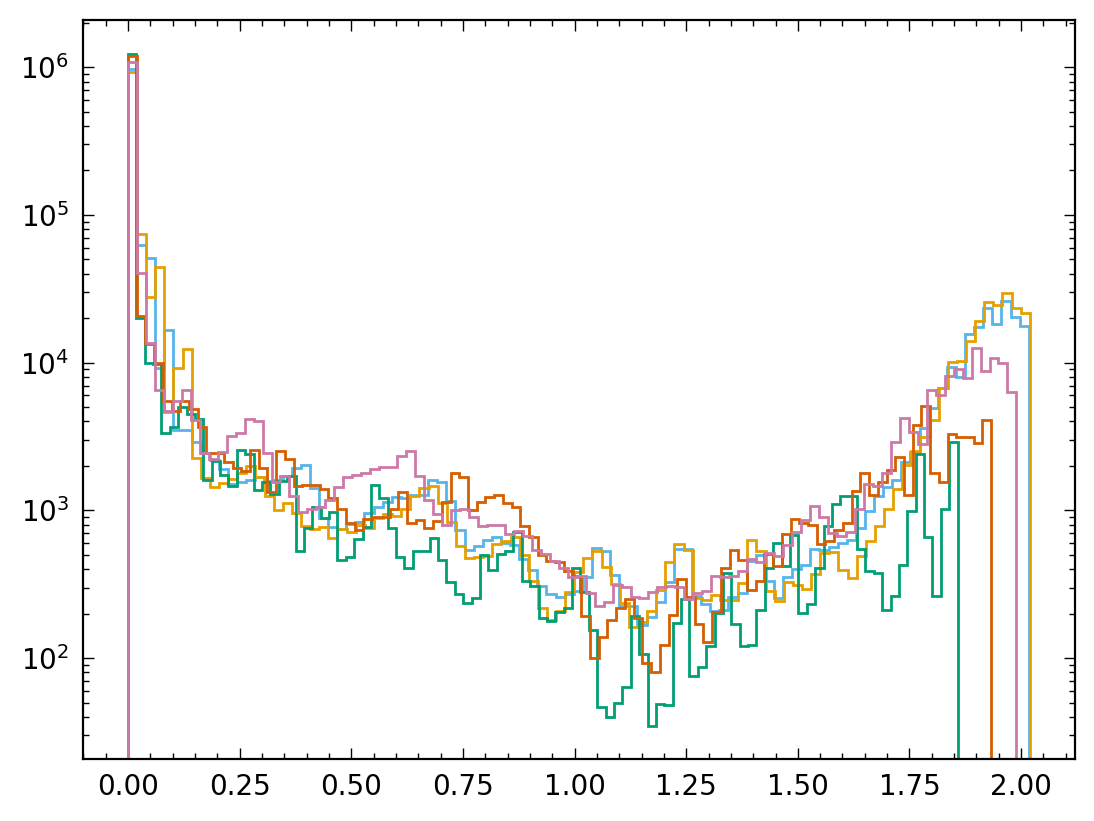

,antigenicity_over_harm,stim_pI,stim_pHI,stim_pHE
0,-26.795884,0.666875,0.056793,0.042333
1,-6.698971,1.284577,0.056204,0.051090
2,0.700124,0.083049,0.106076,0.010399
3,0.717337,0.111202,0.130608,0.011945
4,0.735609,0.137563,0.154091,0.014381
...,...,...,...,...
100,2.677607,1.805007,0.192605,0.023247
101,2.813581,1.928267,0.180782,0.026267
102,3.349485,0.011531,0.062668,0.014042
103,5.359177,0.059453,0.061362,0.016520


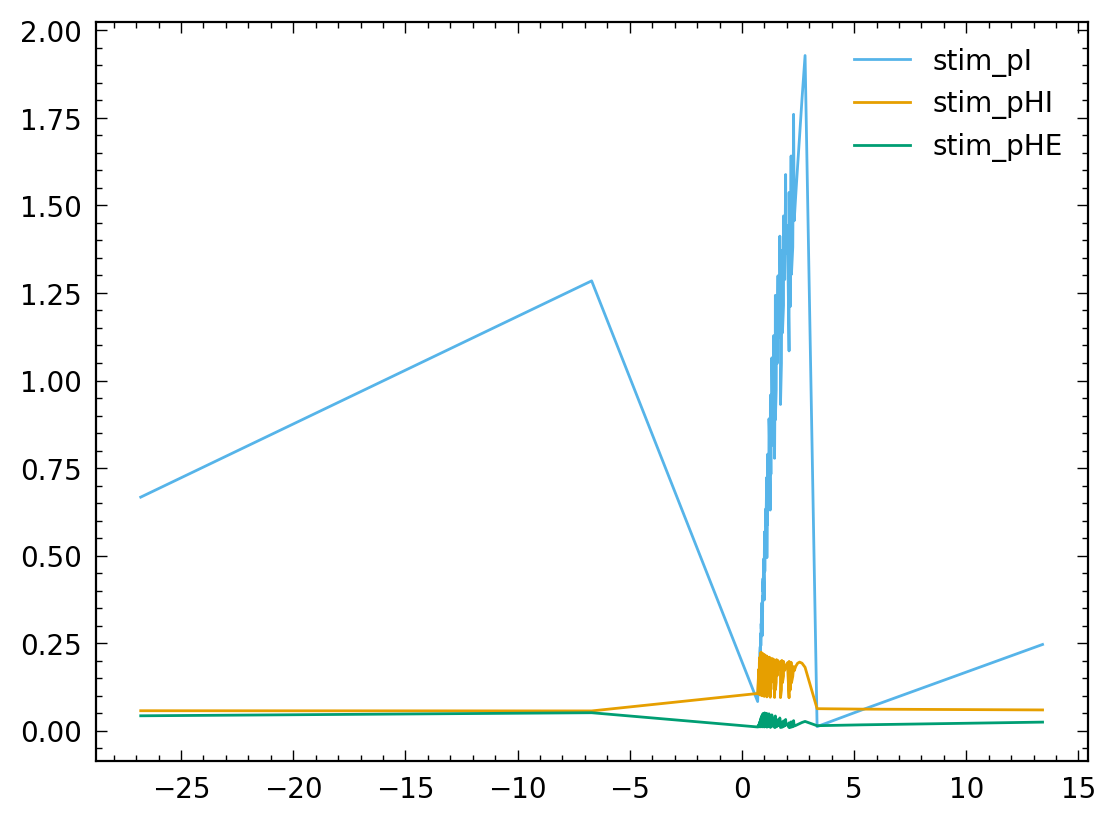

fevals: 13
fevals: 11
fevals: 12
fevals: 11


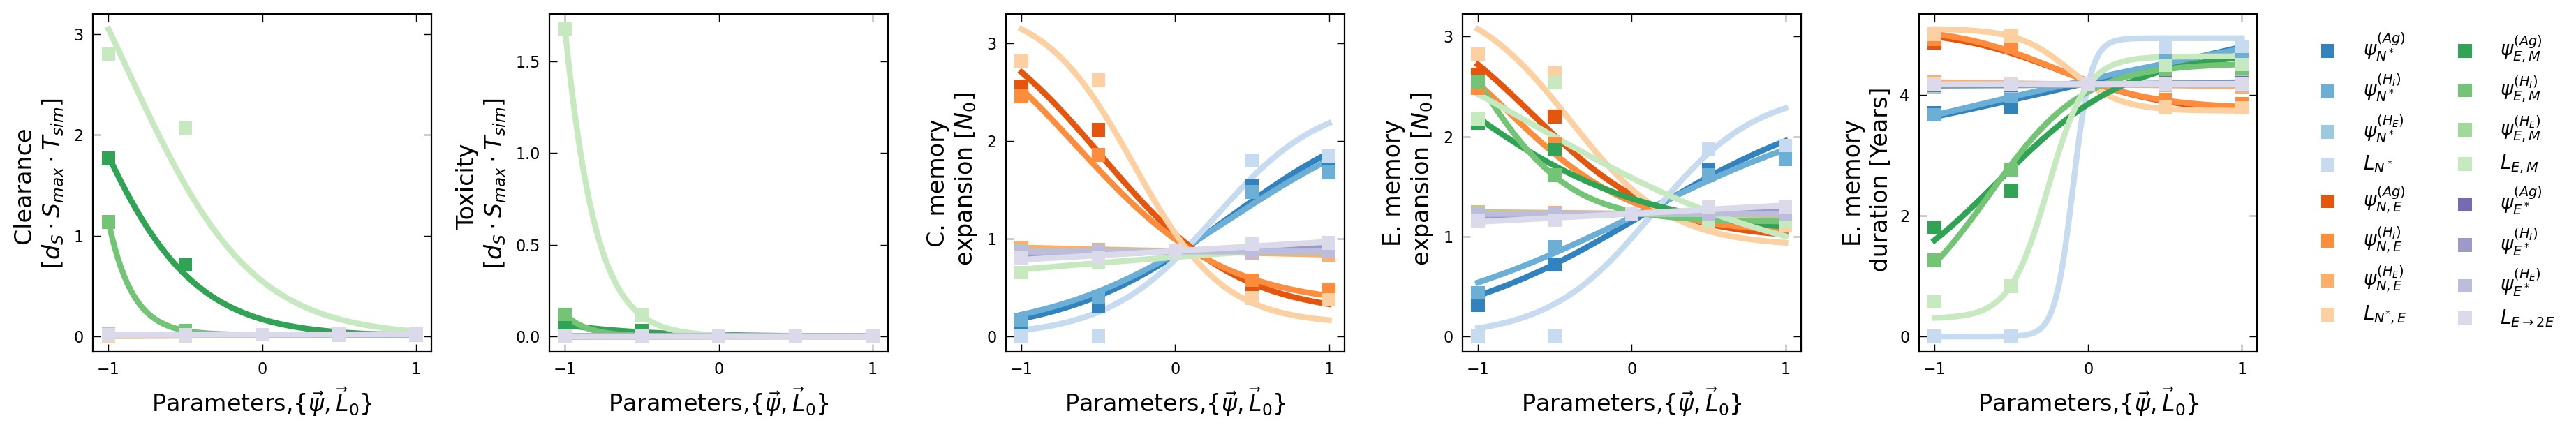

fevals: 12
fevals: 8
fevals: 10
fevals: 9


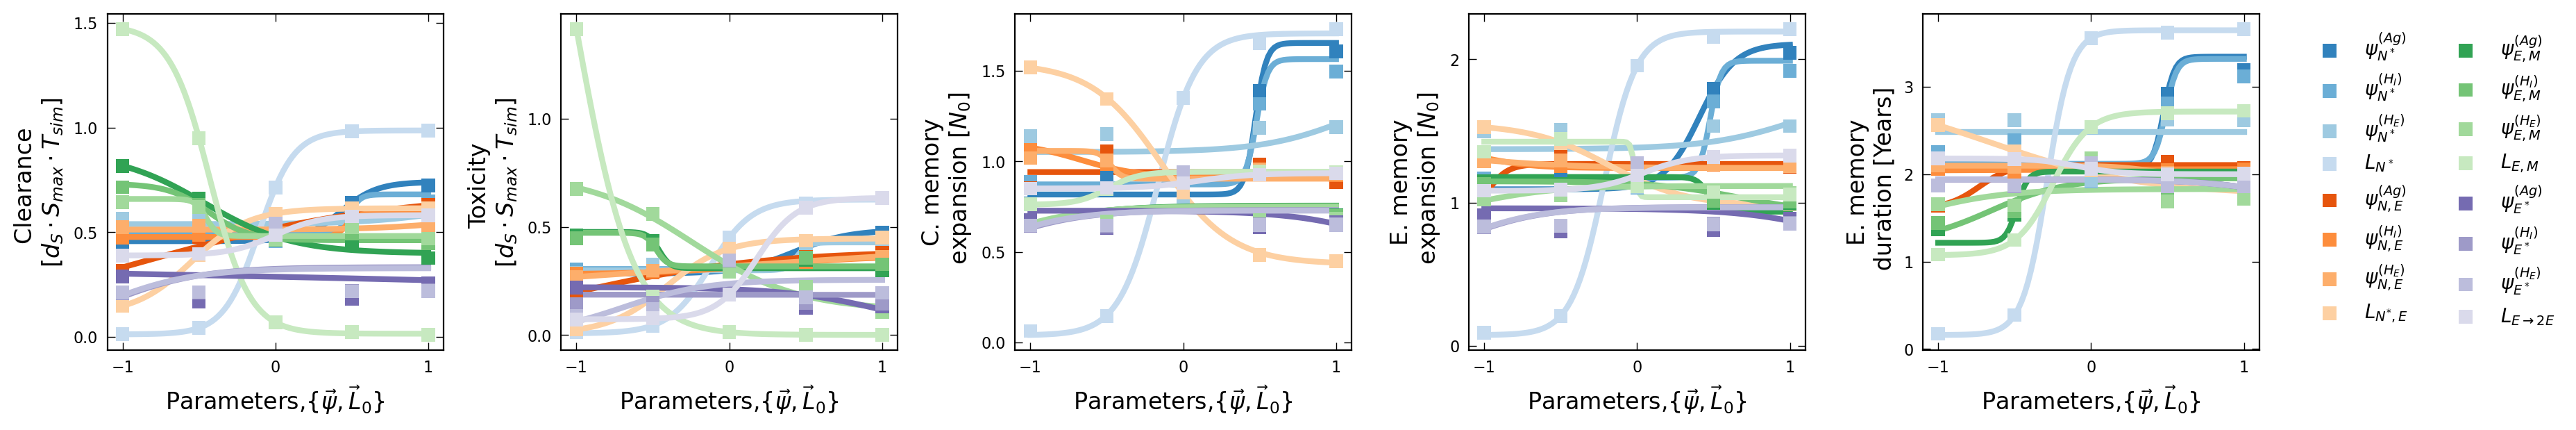

,y_range,y_min,psi_Na_I,psi_Na_HI,psi_Na_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_EE_I,psi_EE_HI,psi_EE_HE,L0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_HI,sigma_psi_Na_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_EE_I,sigma_psi_EE_HI,sigma_psi_EE_HE,sigma_L0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
4,5.000000,0.093068,-0.037620,-0.028561,0.000786,6.438538,-0.029318,-0.048160,0.002245,-0.213771,0.024808,0.030308,0.003990,0.316169,-0.042139,-0.018808,-0.004029,-0.323402,9.931794,2.948820,1.820524,4.662726,0.012700,0.003093,25.534108,25.510235,25.539595,102.597546,0.009051,0.008604,0.008575,0.005203,0.004385,0.004385,0.004388,0.001687,0.023970,0.024268,0.024239,0.016652,24.345879,0.043382,0.011263,0.123434,0.01,100000000.0,0.0,50000.0,100.000000,10000000.0,0.0,1.994224,5.000000,0.0,0.564800,4.0,0.800990,2.154728,0.000000,0.040966,0.022282,0.004979,NaN
9,5.000000,0.093286,-0.038462,-0.026614,-0.006278,6.367738,-0.027389,-0.046423,0.002421,-0.214696,0.023415,0.030255,0.008480,0.319652,-0.041548,-0.019530,-0.004079,-0.323625,10.178787,2.975114,1.806316,4.686303,0.012591,0.003078,32.336288,32.305936,32.342658,62.797525,0.009181,0.008726,0.008697,0.005292,0.004354,0.004354,0.004357,0.001664,0.024338,0.024637,0.024608,0.016970,31.068176,0.044044,0.011023,0.125790,0.01,100000000.0,0.0,50000.0,234.034732,10000000.0,0.0,1.991182,5.000000,0.0,0.565086,4.0,0.798172,2.154631,0.000000,0.040964,0.022282,0.010058,NaN
14,5.000000,0.093348,-0.037983,-0.023753,-0.011346,6.259980,-0.027645,-0.046430,0.000855,-0.215373,0.021841,0.027969,0.012593,0.320864,-0.040959,-0.018071,-0.007247,-0.324004,9.977460,2.989876,1.799962,4.700086,0.012522,0.003070,26.404142,26.378976,26.408048,52.513307,0.009240,0.008782,0.008753,0.005334,0.004336,0.004337,0.004340,0.001654,0.024518,0.024818,0.024788,0.017136,25.345666,0.044347,0.010919,0.126998,0.01,100000000.0,0.0,50000.0,547.722558,10000000.0,0.0,1.990421,5.000000,0.0,0.564652,4.0,0.796425,2.154631,0.000000,0.040959,0.022282,0.018500,NaN
19,4.999889,0.093197,-0.036847,-0.023328,-0.022425,6.277105,-0.028679,-0.046765,0.000475,-0.215394,0.019386,0.025425,0.014301,0.320942,-0.042224,-0.019492,-0.010556,-0.324217,9.998643,2.995537,1.799613,4.708793,0.012482,0.003062,26.888190,26.860710,26.890450,54.403781,0.009249,0.008791,0.008762,0.005345,0.004323,0.004323,0.004327,0.001649,0.024594,0.024896,0.024866,0.017214,25.815304,0.044437,0.010883,0.127575,0.01,100000000.0,0.0,50000.0,1281.861019,10000000.0,0.0,1.991169,4.999889,0.0,0.567255,4.0,0.794486,2.154411,0.000000,0.040948,0.022282,0.030833,NaN
24,4.999847,0.092862,-0.037114,-0.023846,-0.042962,6.316781,-0.030441,-0.048052,-0.001122,-0.215327,0.018743,0.023017,0.015160,0.319980,-0.043016,-0.019528,-0.016695,-0.324001,10.070048,2.998443,1.802303,4.712426,0.012447,0.003053,28.691324,28.658002,28.686885,57.953231,0.009230,0.008775,0.008746,0.005340,0.004309,0.004309,0.004313,0.001646,0.024606,0.024908,0.024878,0.017223,27.635671,0.044398,0.010889,0.127656,0.01,100000000.0,0.0,50000.0,3000.000000,10000000.0,0.0,1.993204,4.999847,0.0,0.569148,4.0,0.792203,2.154066,0.000000,0.040924,0.022282,0.047403,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629,5.000000,0.099003,0.732359,4.127611,-0.003248,3.493519,-0.031171,-0.116603,-0.000693,-0.207511,0.020868,0.176879,-0.014847,0.314598,-0.075623,-0.058732,-0.008900,-0.391061,5.723218,2.859087,1.805640,5.924226,0.012767,0.002

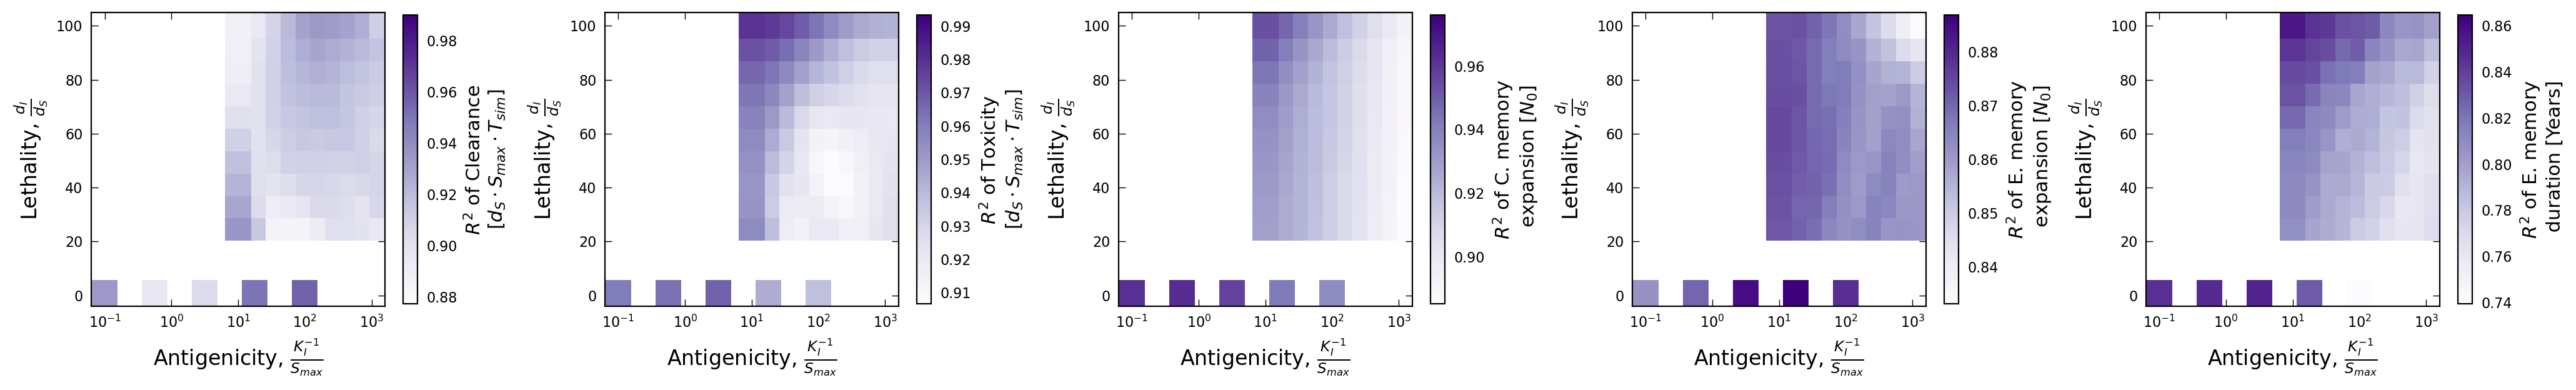

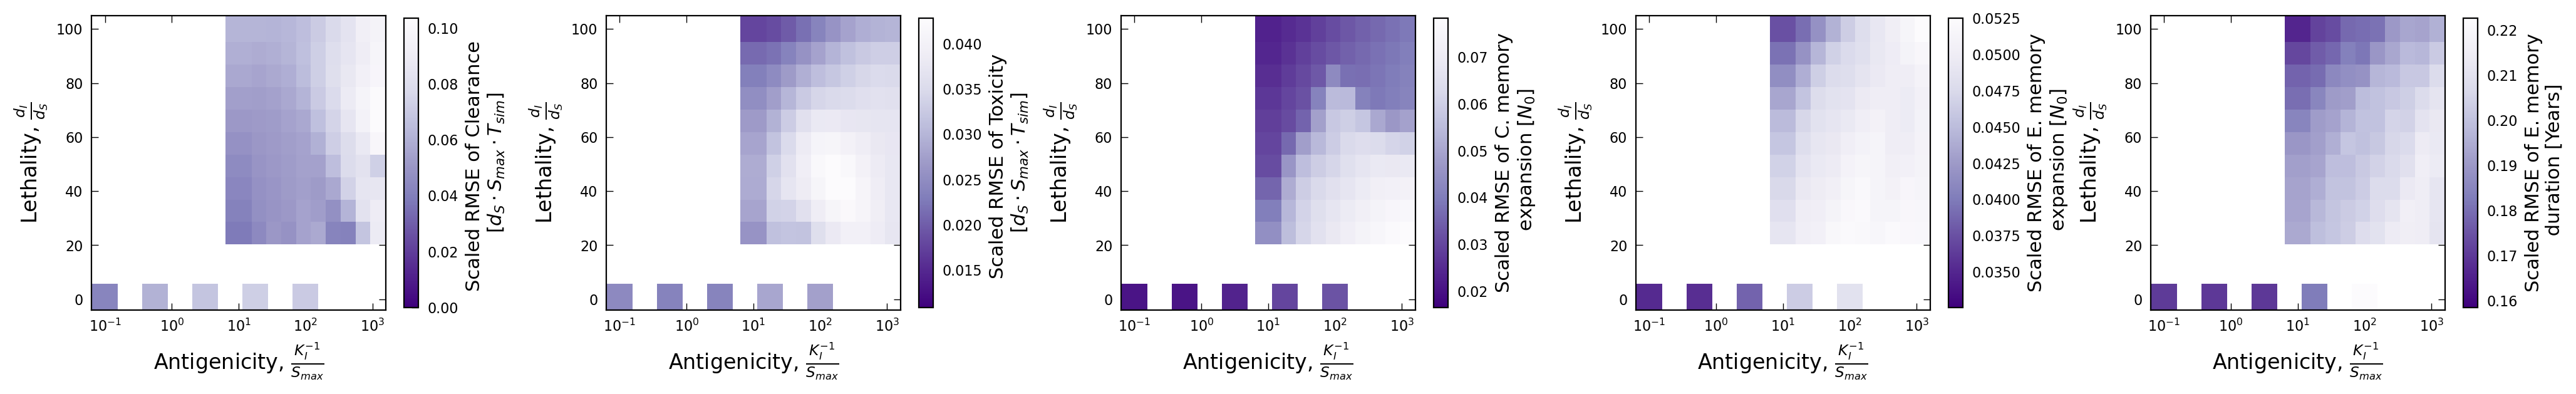

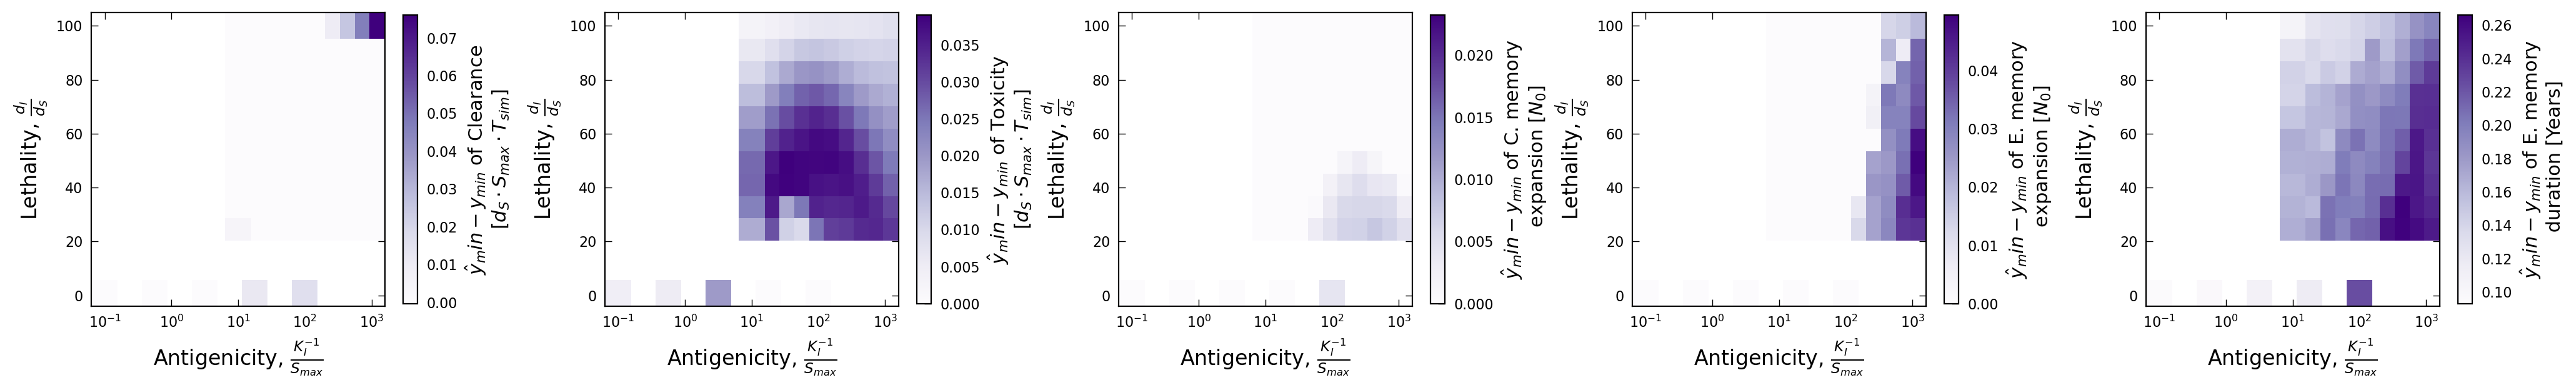

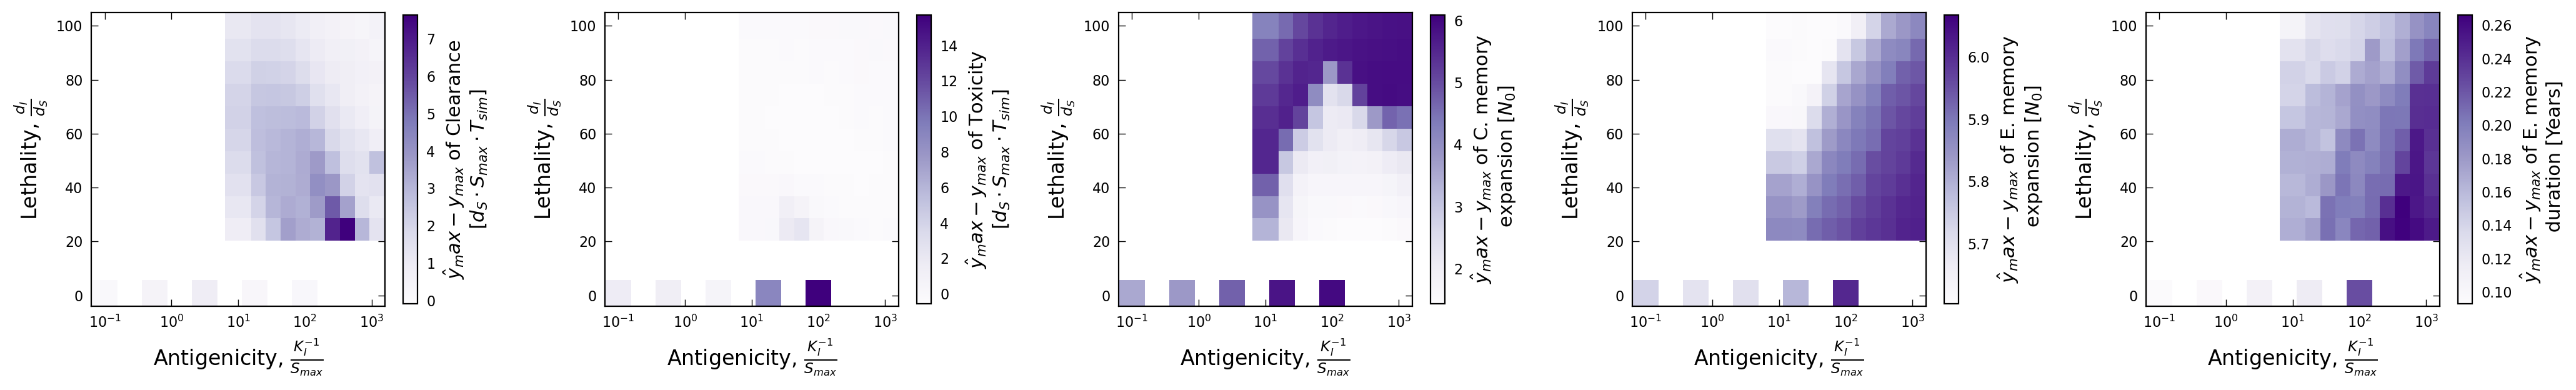

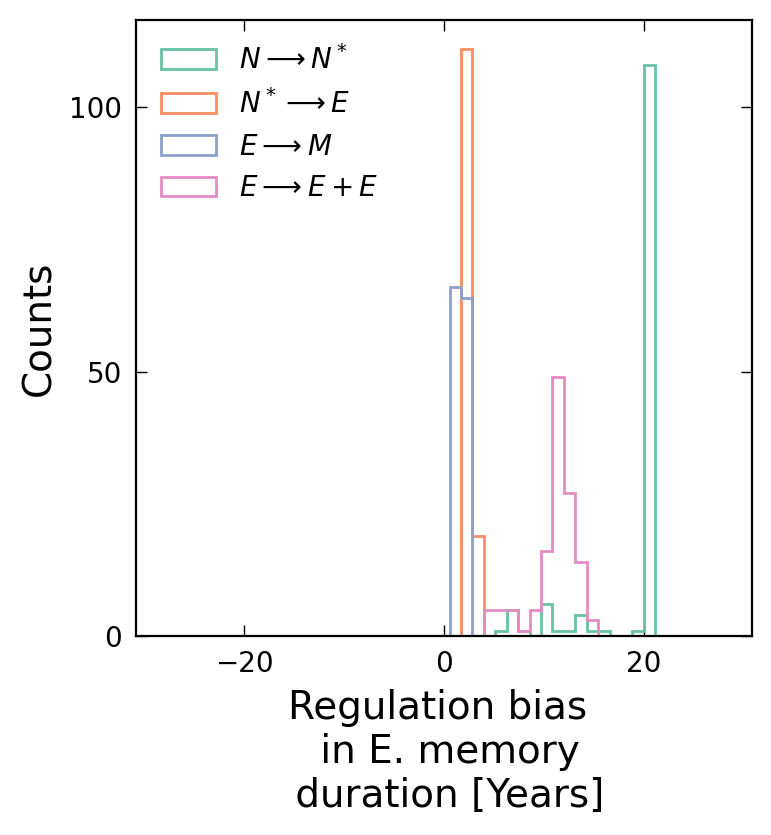

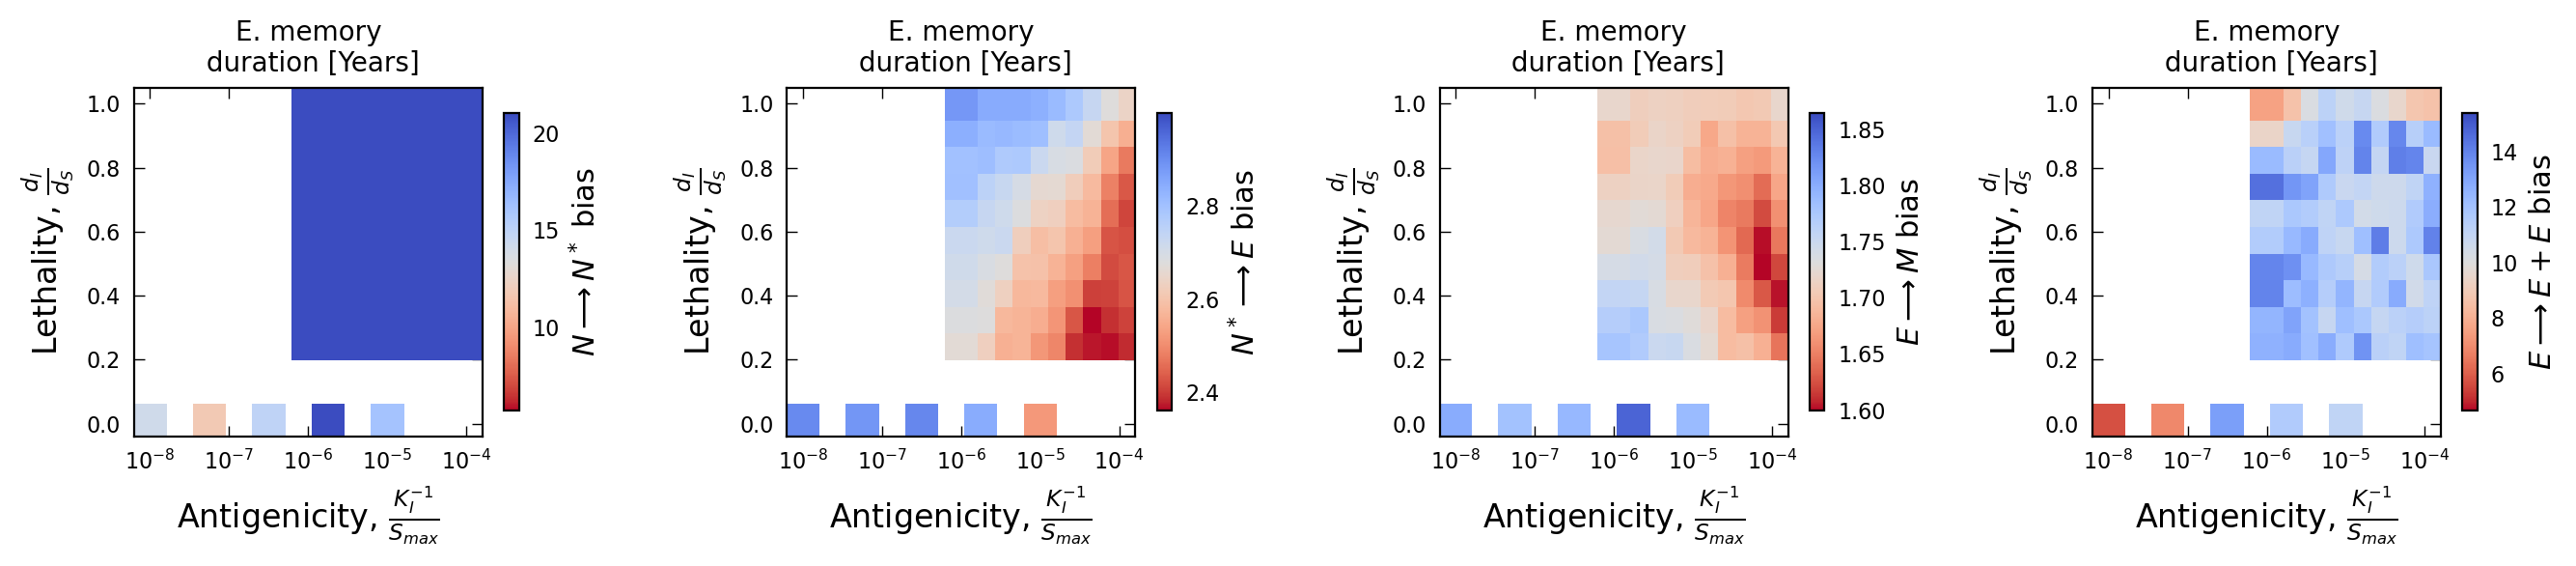

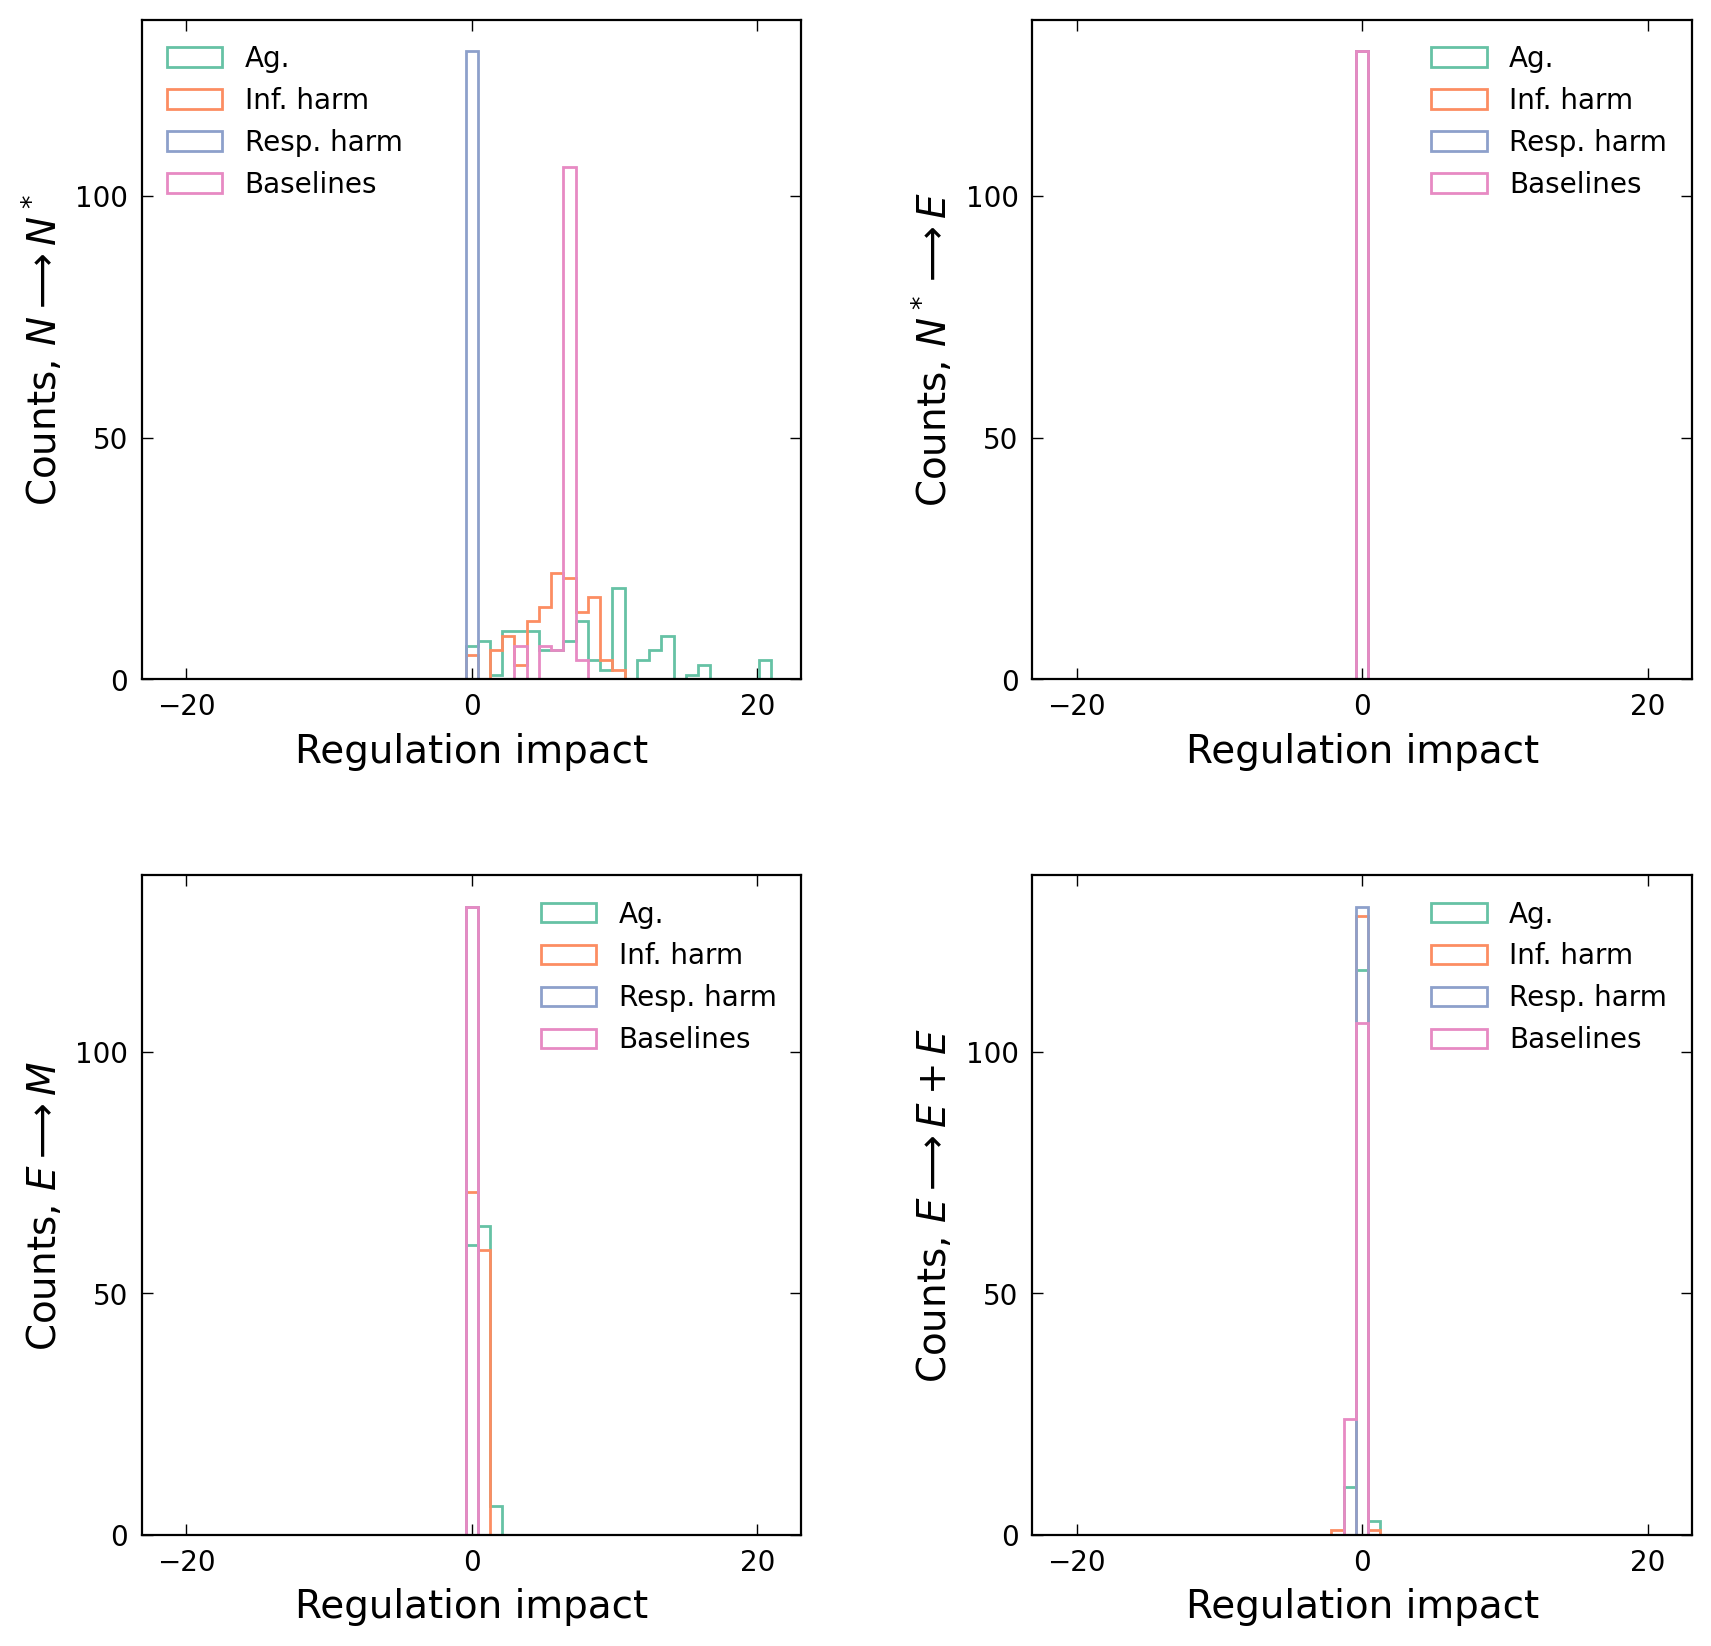

,y_range,y_min,psi_Na_I,psi_Na_HI,psi_Na_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_EE_I,psi_EE_HI,psi_EE_HE,L0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_HI,sigma_psi_Na_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_EE_I,sigma_psi_EE_HI,sigma_psi_EE_HE,sigma_L0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
4,5.000000,0.093068,-0.037620,-0.028561,0.000786,6.438538,-0.029318,-0.048160,0.002245,-0.213771,0.024808,0.030308,0.003990,0.316169,-0.042139,-0.018808,-0.004029,-0.323402,9.931794,2.948820,1.820524,4.662726,0.012700,0.003093,25.534108,25.510235,25.539595,102.597546,0.009051,0.008604,0.008575,0.005203,0.004385,0.004385,0.004388,0.001687,0.023970,0.024268,0.024239,0.016652,24.345879,0.043382,0.011263,0.123434,0.01,100000000.0,0.0,50000.0,100.000000,10000000.0,0.0,1.994224,5.000000,0.0,0.564800,4.0,0.800990,2.154728,0.0,0.040966,0.022282,0.004979,NaN
9,5.000000,0.093286,-0.038462,-0.026614,-0.006278,6.367738,-0.027389,-0.046423,0.002421,-0.214696,0.023415,0.030255,0.008480,0.319652,-0.041548,-0.019530,-0.004079,-0.323625,10.178787,2.975114,1.806316,4.686303,0.012591,0.003078,32.336288,32.305936,32.342658,62.797525,0.009181,0.008726,0.008697,0.005292,0.004354,0.004354,0.004357,0.001664,0.024338,0.024637,0.024608,0.016970,31.068176,0.044044,0.011023,0.125790,0.01,100000000.0,0.0,50000.0,234.034732,10000000.0,0.0,1.991182,5.000000,0.0,0.565086,4.0,0.798172,2.154631,0.0,0.040964,0.022282,0.010058,NaN
14,5.000000,0.093348,-0.037983,-0.023753,-0.011346,6.259980,-0.027645,-0.046430,0.000855,-0.215373,0.021841,0.027969,0.012593,0.320864,-0.040959,-0.018071,-0.007247,-0.324004,9.977460,2.989876,1.799962,4.700086,0.012522,0.003070,26.404142,26.378976,26.408048,52.513307,0.009240,0.008782,0.008753,0.005334,0.004336,0.004337,0.004340,0.001654,0.024518,0.024818,0.024788,0.017136,25.345666,0.044347,0.010919,0.126998,0.01,100000000.0,0.0,50000.0,547.722558,10000000.0,0.0,1.990421,5.000000,0.0,0.564652,4.0,0.796425,2.154631,0.0,0.040959,0.022282,0.018500,NaN
19,4.999889,0.093197,-0.036847,-0.023328,-0.022425,6.277105,-0.028679,-0.046765,0.000475,-0.215394,0.019386,0.025425,0.014301,0.320942,-0.042224,-0.019492,-0.010556,-0.324217,9.998643,2.995537,1.799613,4.708793,0.012482,0.003062,26.888190,26.860710,26.890450,54.403781,0.009249,0.008791,0.008762,0.005345,0.004323,0.004323,0.004327,0.001649,0.024594,0.024896,0.024866,0.017214,25.815304,0.044437,0.010883,0.127575,0.01,100000000.0,0.0,50000.0,1281.861019,10000000.0,0.0,1.991169,4.999889,0.0,0.567255,4.0,0.794486,2.154411,0.0,0.040948,0.022282,0.030833,NaN
24,4.999847,0.092862,-0.037114,-0.023846,-0.042962,6.316781,-0.030441,-0.048052,-0.001122,-0.215327,0.018743,0.023017,0.015160,0.319980,-0.043016,-0.019528,-0.016695,-0.324001,10.070048,2.998443,1.802303,4.712426,0.012447,0.003053,28.691324,28.658002,28.686885,57.953231,0.009230,0.008775,0.008746,0.005340,0.004309,0.004309,0.004313,0.001646,0.024606,0.024908,0.024878,0.017223,27.635671,0.044398,0.010889,0.127656,0.01,100000000.0,0.0,50000.0,3000.000000,10000000.0,0.0,1.993204,4.999847,0.0,0.569148,4.0,0.792203,2.154066,0.0,0.040924,0.022282,0.047403,NaN


,y_range,y_min,psi_Na_I,psi_Na_HI,psi_Na_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_EE_I,psi_EE_HI,psi_EE_HE,L0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_HI,sigma_psi_Na_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_EE_I,sigma_psi_EE_HI,sigma_psi_EE_HE,sigma_L0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
529,5.0,0.116940,20.999918,6.782280,-0.038989,6.663091,-0.296050,-0.078560,-0.022248,-0.209578,1.172233,0.383973,0.049220,0.365030,-0.071642,-0.036313,-0.010841,-0.020702,19.999656,2.577011,1.863965,11.551050,0.402190,0.003154,0.246826,0.087206,0.021768,0.079022,0.007822,0.007005,0.006961,0.003855,0.008011,0.005969,0.005668,0.001810,586.694360,308.123226,134.814908,171.906423,0.246990,0.032807,0.011080,8402.025091,0.01,1.000000e+05,0.1,50000.0,100.000000,10000000.0,1000000.0,2.033743,5.0,0.0,0.575859,4.0,0.888126,2.187411,2.651379,1.352211,0.058333,0.024001,-6.698971
534,5.0,0.143340,20.999040,6.789205,-0.032575,6.659537,-0.287300,-0.074507,-0.032792,-0.209971,1.121762,0.368466,0.098538,0.365760,0.277816,0.084387,0.007878,-0.486512,20.090704,2.609806,1.845105,15.357811,0.012424,0.003206,0.245279,0.087517,0.022487,0.078256,0.008063,0.007253,0.007218,0.004023,0.007865,0.005962,0.005698,0.001824,293.986749,301.582993,299.654965,411.140620,0.248037,0.034181,0.011101,2953.894919,0.01,1.000000e+05,0.1,50000.0,234.034732,10000000.0,1000000.0,2.064713,5.0,0.0,0.633256,4.0,0.900291,2.189986,2.651379,1.306726,0.056710,0.029892,-6.698971
539,5.0,0.184057,20.996269,6.783679,-0.024574,6.639953,-0.280020,-0.072628,-0.040660,-0.206525,1.049541,0.336770,0.158472,0.364916,-0.031364,-0.025585,-0.013700,0.025296,20.365820,2.581864,1.814171,11.765907,0.448116,0.003328,0.261166,0.095317,0.024616,0.081282,0.008304,0.007467,0.007437,0.004136,0.007796,0.006037,0.005846,0.001872,375.664420,316.566772,204.065977,290.074092,0.269505,0.035369,0.011331,11628.826036,0.01,1.000000e+05,0.1,50000.0,547.722558,10000000.0,1000000.0,2.106571,5.0,0.0,0.773330,4.0,0.928396,2.182694,2.651379,1.272237,0.055760,0.042749,-6.698971
544,5.0,0.213807,20.192860,6.305795,-0.014826,6.287600,-0.274490,-0.071113,-0.046859,-0.203275,0.934701,0.298152,0.229943,0.362575,0.068362,0.011738,-0.015956,0.031201,20.014010,2.544748,1.794395,11.886787,0.290993,0.003615,0.607409,0.161196,0.026590,0.175637,0.008834,0.007933,0.007908,0.004379,0.007878,0.006328,0.006245,0.002006,572.796639,186.940591,205.538351,260.950046,0.612989,0.037693,0.012136,8550.500813,0.01,1.000000e+05,0.1,50000.0,1281.861019,10000000.0,1000000.0,2.171147,5.0,0.0,0.963391,4.0,0.997513,2.173816,2.651379,1.253388,0.055355,0.065490,-6.698971
549,5.0,0.224887,15.852022,4.255936,-0.009585,4.947068,-0.272118,-0.070716,-0.053996,-0.201809,0.790033,0.241136,0.296939,0.356364,0.315809,0.093321,-0.022577,0.093872,16.146732,2.519930,1.788335,11.090135,0.033959,0.004096,1.389135,0.088710,0.024430,0.397999,0.009697,0.008701,0.008682,0.004792,0.008112,0.006797,0.006881,0.002227,92.983142,59.283523,55.829195,33.270942,1.392755,0.041369,0.013614,428.247714,0.01,1.000000e+05,0.1,50000.0,3000.000000,10000000.0,1000000.0,2.254404,5.0,0.0,1.376245,4.0,1.113443,2.181211,2.651379,1.238321,0.054864,0.093320,-6.698971
554,5.0,0.114260,13.130831,8.481092,0.009656,7.111184,-0.128895,-0.084967,-0.016766,-0.220302,0.503645,0.334247,0.010518,0.373118,-0.057857,-0.026171,-0.006645,-0.011942,20.999769,2.700818,1.856432,12.428459,0.852999,0.003149,0.196617,0.127443,0.015698,0.107929,0.008143,0.007744,0.007693,0.004359,0.005719,0.005464,0.005250,0.001835,2436.251615,1117.835000,374.148046,507.161155,0.321057,0.036021,0.011090,42711.445112,0.01,5.623413e+05

In [6]:
%run ./fit-observables.ipynb